# Clustering con K-Means + PCA

## Descripción general

Este notebook aplica el algoritmo **K-Means** sobre las calificaciones de un grupo de **estudiantes** en 5 materias (Matemática, Ciencias, Español, Historia y Educación Física) para encontrar grupos de alumnos con perfiles académicos parecidos.

Pasos que se realizan:

1. Importar librerías y definir funciones auxiliares para graficar.
2. Cargar el archivo de datos `Estudiantes.xlsx`.
3. Aplicar K-Means con 3 clusters.
4. Interpretar los centros con gráficos de **barras** y **radar**.
5. Aplicar **PCA** para visualizar los clusters en 2 dimensiones, mostrando el **nombre de cada estudiante**.

## 1. Importar librerías

Se importan las librerías necesarias:

- `pandas` para manejar la tabla de datos.
- `matplotlib.pyplot` para graficar.
- `numpy` para operaciones numéricas.
- `PCA` de `sklearn` para reducir las dimensiones a 2.
- `KMeans` de `sklearn` para hacer el clustering.
- `pi` de `math` para los gráficos polares (radar).

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from   sklearn.decomposition import PCA   #se usa el analisis de componentes
from   sklearn.cluster import KMeans   #ahora se hace con la sklearn.cluster , el otro habia sido con scipy
import numpy as np
from   math import pi

## 2. Función auxiliar: `centroide`

Función que calcula el **centroide** (promedio de cada variable) de un cluster específico.

- Recibe el número de cluster, los datos y la lista de etiquetas (`clusters`).
- Filtra los registros que pertenecen a ese cluster y devuelve la **media** de cada columna en un `DataFrame` de una fila.

In [ ]:
#funcion de centroides
def centroide(num_cluster, datos, clusters):
    ind = clusters == num_cluster
    return(pd.DataFrame(datos[ind].mean()).T)

## 3. Función auxiliar: `bar_plot`

Función para dibujar un **gráfico de barras horizontales por cada cluster**, mostrando el valor del centroide en cada variable.

Parámetros:

- `centros`: matriz con las coordenadas de los centroides.
- `labels`: nombres de las variables (columnas).
- `scale`: si es `True`, normaliza los valores entre 0 y 1.
- `cluster`: lista opcional para graficar solo ciertos clusters.
- `var`: lista opcional para graficar solo ciertas variables.

Resultado: un panel de subplots, uno por cluster, donde cada barra representa una variable.

In [ ]:
def bar_plot(centros, labels, scale = False,cluster = None, var = None):
    from math import ceil, floor
    from seaborn import color_palette

    centros = np.copy(centros)

    if scale:
        for col in range(centros.shape[1]):
            centros[:,col] /= max(centros[:,col])

    colores = color_palette()
    minimo = floor(centros.min()) if floor(centros.min()) < 0 else 0
    def inside_plot(valores, labels, titulo):
        plt.barh(range(len(valores)), valores, 1/1.5, color = colores)
        plt.xlim(minimo, ceil(centros.max()))
        plt.title(titulo)
    if var is not None:
        centros = np.array([n[[x in var for x in labels]] for n in centros])
        colores = [colores[x % len(colores)] for x, i in enumerate(labels) if i in var]
        labels = labels[[x in var for x in labels]]
    if cluster is None:
        for i in range(centros.shape[0]):
            plt.subplot(1, centros.shape[0], i + 1)
            inside_plot(centros[i].tolist(), labels, ('Cluster ' + str(i)))
            plt.yticks(range(len(labels)), labels) if i == 0 else plt.yticks([])
    else:
        pos = 1
        for i in cluster:
            plt.subplot(1, len(cluster), pos)
            inside_plot(centros[i].tolist(), labels, ('Cluster ' + str(i)))
            plt.yticks(range(len(labels)), labels) if pos == 1 else plt.yticks([])
            pos += 1

## 4. Función auxiliar: `bar_plot_detail`

Versión más detallada del gráfico de barras: en lugar de un panel por cluster, dibuja **un panel por variable** comparando todos los clusters entre sí.

Es útil para responder: *¿en qué materia destaca más cada cluster?*

Usa `seaborn.barplot` y organiza los subplots en 2 columnas.

In [ ]:
def bar_plot_detail(centros,columns_names = [], columns_to_plot = [],figsize = (10,7),dpi = 150):
  from math import ceil, floor
  import seaborn as sb
  numClusters = centros.shape[0]
  labels = ["Cluster "+ str(i) for i in range(numClusters)]
  centros = pd.DataFrame(centros,columns=columns_names,index= labels)

  plots = len(columns_to_plot) if len(columns_to_plot) != 0 else len(columns_names)
  rows, cols = ceil(plots/2),2

  plt.figure(1, figsize = figsize,dpi = dpi)
  plt.subplots_adjust(hspace=1,wspace = 0.5)
  columns = columns_names
  if len(columns_to_plot) > 0:
    if type(columns_to_plot[0]) is str:
      columns = columns_to_plot
    else:
      columns = [columns_names[i] for i in columns_to_plot]
  var = 0
  for numRow in range(rows):
    for numCol in range(cols):
      if var < plots:
        ax = plt.subplot2grid((rows, cols), (numRow, numCol), colspan=1, rowspan=1)
        sb.barplot(y = labels, x=columns[var] ,data=centros ,ax=ax)
        var += 1

## 5. Función auxiliar: `radar_plot`

Función que genera un **gráfico de radar (telaraña)** para comparar visualmente los perfiles de los clusters.

- Cada eje del radar es una variable (materia).
- Cada polígono representa un cluster.
- Los valores se **normalizan a porcentaje (0–100%)** para que sean comparables.

Es muy útil para ver de un vistazo en qué materias es fuerte o débil cada grupo.

In [ ]:
def radar_plot(centros, labels):
    from math import pi
    centros = np.array([((n - min(n)) / (max(n) - min(n)) * 100) if
                        max(n) != min(n) else (n/n * 50) for n in centros.T])
    angulos = [n / float(len(labels)) * 2 * pi for n in range(len(labels))]
    angulos += angulos[:1]
    ax = plt.subplot(111, polar = True)
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)

    plt.xticks(angulos[:-1], labels)
    ax.set_rlabel_position(0)
    plt.yticks([10, 20, 30, 40, 50, 60, 70, 80, 90, 100],
           ["10%", "20%", "30%", "40%", "50%", "60%", "70%", "80%", "90%", "100%"],
           color = "grey", size = 8)
    plt.ylim(-10, 100)
    for i in range(centros.shape[1]):
        valores = centros[:, i].tolist()
        valores += valores[:1]
        ax.plot(angulos, valores, linewidth = 1, linestyle = 'solid',
                label = 'Cluster ' + str(i))
        ax.fill(angulos, valores, alpha = 0.3)
    plt.legend(loc='upper right', bbox_to_anchor = (0.1, 0.1))

## 6. Cargar los datos

Se lee el archivo Excel `Estudiantes.xlsx` que contiene las calificaciones de los estudiantes.

Después se imprime el `shape` para verificar **cuántas filas (estudiantes) y columnas (materias)** tiene la tabla.

In [ ]:
datos = pd.read_excel('/content/Estudiantes.xlsx')
print(datos.shape)

(10, 6)


## 7. Preparar el índice

Se establece la columna **`Nombre`** como índice del `DataFrame`.

Esto sirve para:

- Que K-Means solo use las columnas numéricas (las calificaciones).
- Poder identificar a cada estudiante por su nombre más adelante (por ejemplo, en el gráfico del PCA).

`datos.head()` muestra las primeras filas para verificar el resultado.

In [ ]:
datos.set_index('Nombre', inplace=True)
datos.head()

,Matematica,Ciencias,Español,Historia,Educacion F
Nombre,,,,,
Lucia,7.0,6.5,9.2,8.6,8.0
Pedro,7.5,9.4,7.3,7.0,7.0
Ines,7.6,9.2,8.0,8.0,7.5
Luis,5.0,6.5,6.5,7.0,9.0
Andres,6.0,6.0,7.8,8.9,7.3


## 8. Aplicar K-Means

Se entrena el modelo **K-Means con 3 clusters**:

- `KMeans(n_clusters=3)` crea la instancia.
- `.fit(datos)` ejecuta el algoritmo: inicializa los centros, asigna cada estudiante al centro más cercano y actualiza los centros hasta converger.

Al finalizar, el modelo conoce los **3 grupos de estudiantes** y dónde está el centro de cada grupo.

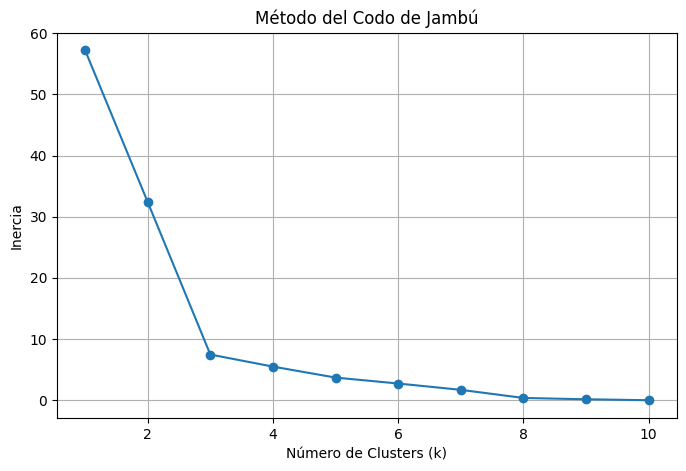

In [ ]:
#solo el metodo de jambu
def codo_jambu(X, max_k=10):
    inercias = []

    for k in range(1, max_k + 1):
        modelo = KMeans(n_clusters=k, random_state=42)
        modelo.fit(X)
        inercias.append(modelo.inertia_)

    plt.figure(figsize=(8,5))
    plt.plot(range(1, max_k + 1), inercias, marker='o')
    plt.title("Método del Codo de Jambú")
    plt.xlabel("Número de Clusters (k)")
    plt.ylabel("Inercia")
    plt.grid(True)
    plt.show()

codo_jambu(datos)

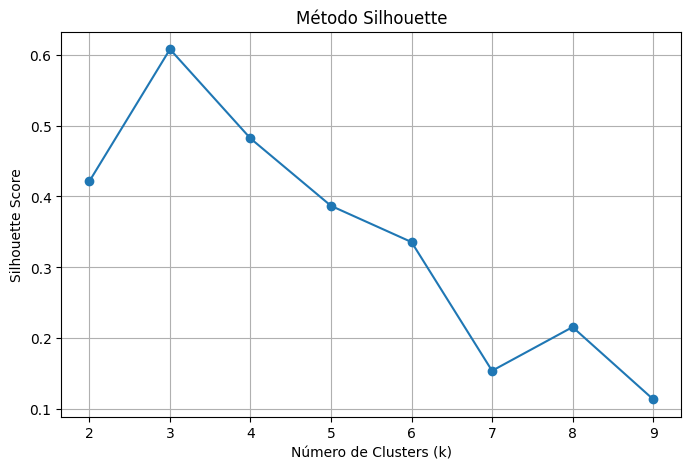

In [ ]:
#grafico de silhouette
from sklearn.metrics import silhouette_score

def silhouette_kmeans(X, max_k=10):

    max_k = min(max_k, len(X) - 1)

    scores = []

    for k in range(2, max_k + 1):
        modelo = KMeans(n_clusters=k, random_state=42)
        etiquetas = modelo.fit_predict(X)

        score = silhouette_score(X, etiquetas)
        scores.append(score)

    plt.figure(figsize=(8,5))
    plt.plot(range(2, max_k + 1), scores, marker='o')
    plt.title("Método Silhouette")
    plt.xlabel("Número de Clusters (k)")
    plt.ylabel("Silhouette Score")
    plt.grid(True)
    plt.show()

silhouette_kmeans(datos)

In [ ]:
#aqui se entrena el modelo
kmedias = KMeans(n_clusters=3)
kmedias.fit(datos)

KMeans(n_clusters=3)

## 9. Obtener las etiquetas de cluster

`kmedias.predict(datos)` devuelve, para cada estudiante, el número del cluster al que fue asignado (0, 1 o 2).

El orden de las etiquetas coincide con el orden de las filas del `DataFrame`.

In [ ]:
#se uso k means predict para que salgan los clusters
print("Grupos\n",kmedias.predict(datos))

Grupos
 [0 2 2 1 0 2 0 2 1 0]


## 10. Obtener los centros de cada cluster

`kmedias.cluster_centers_` devuelve una matriz con las coordenadas de los **3 centroides** en el espacio original de las 5 materias.

Cada fila es un cluster y cada columna es una materia. Estos valores son el **perfil promedio** del cluster.

In [ ]:
centros = np.array(kmedias.cluster_centers_)
print("Centros\n",centros)

Centros
 [[6.525 6.525 8.475 8.875 7.375]
 [5.5   6.25  6.5   6.25  8.85 ]
 [7.7   9.475 7.625 7.75  6.75 ]]


## 11. Visualizar los centros con `bar_plot`

Se grafican los centroides con la función `bar_plot` definida antes.

Cada subplot corresponde a un cluster, y dentro se ven las **calificaciones promedio** del grupo en cada materia. Permite responder rápidamente: *¿cómo es el estudiante típico de cada cluster?*

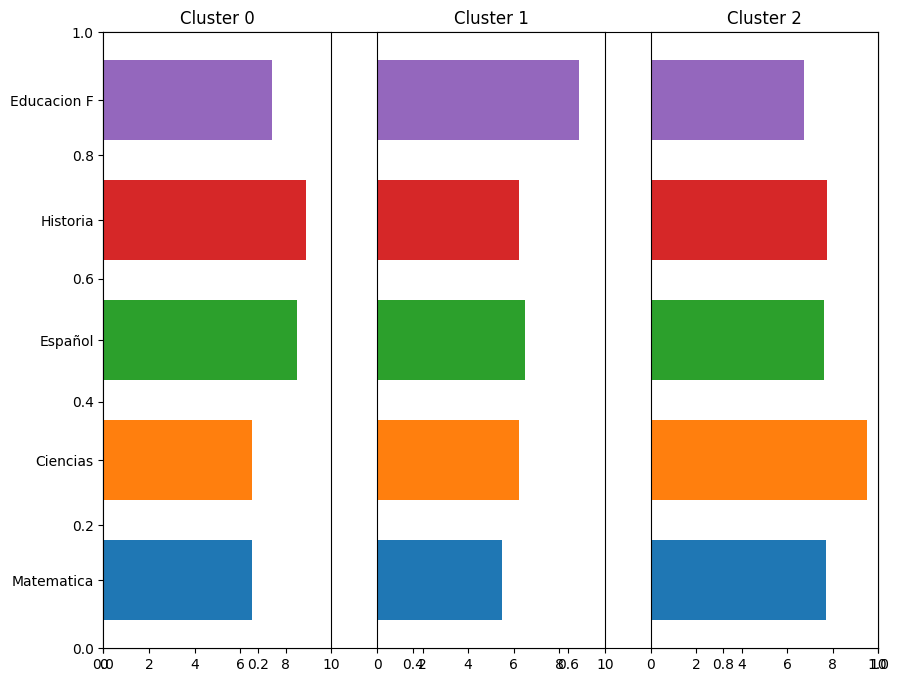

In [ ]:
#usa la media de los clusters
fig, ax = plt.subplots(1,1, figsize = (10,8), dpi = 100)
bar_plot(centros, datos.columns)
plt.show()

## 12. Visualizar los centros con gráfico de radar

Se dibuja el mismo perfil de los clusters pero en un **gráfico de telaraña**:

- Cada eje es una materia.
- Cada polígono coloreado es un cluster.

Esta vista hace evidente las **fortalezas y debilidades académicas** de cada grupo y facilita la comparación.

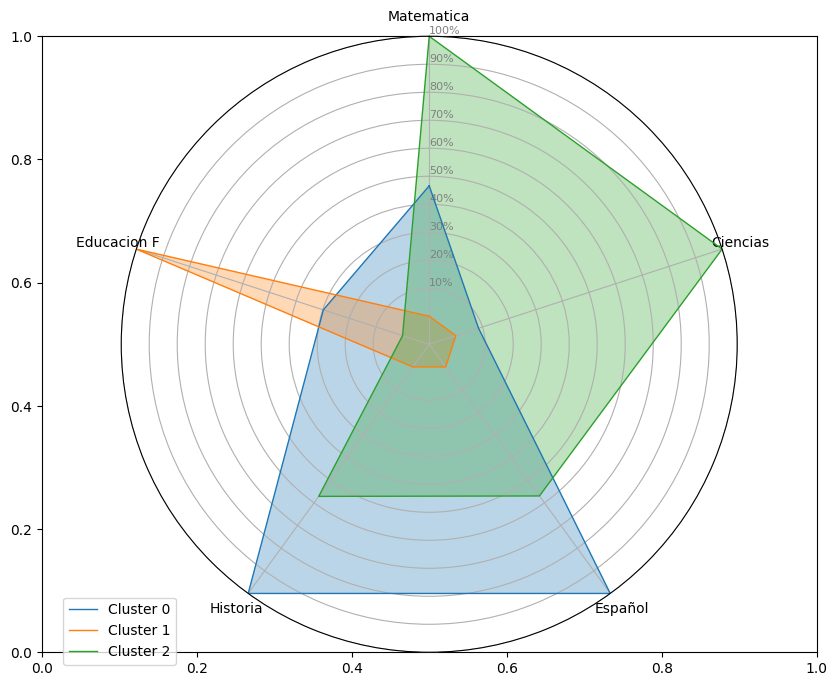

In [ ]:
fig, ax = plt.subplots(1,1, figsize = (10,8), dpi = 100)
radar_plot(centros, datos.columns)
plt.show()

## 13. Reducción de dimensiones con PCA

Los datos tienen **5 dimensiones** (una por materia), así que no podemos graficarlos directamente.

Aplicamos **PCA (Análisis de Componentes Principales)** para proyectarlos en solo **2 dimensiones** conservando la mayor cantidad posible de información (varianza).

- `PCA(n_components=2)` crea el modelo.
- `pca.fit_transform(datos)` calcula y aplica la proyección.
- `componentes` contiene las nuevas coordenadas 2D de cada estudiante.

In [ ]:
pca = PCA(n_components=2)
componentes = pca.fit_transform(datos)
print("Datos shape\n",datos.shape)

Datos shape
 (10, 5)


## 14. Mostrar las componentes

Se imprimen las **coordenadas 2D** que generó el PCA para cada estudiante.

Cada fila corresponde a un alumno (en el mismo orden de `datos`) y cada columna a uno de los dos componentes principales.

In [ ]:
print("Componentes\n",componentes)

Componentes
 [[-0.76471745  1.5817637 ]
 [ 1.66887794 -1.39196556]
 [ 1.57822841 -0.29949595]
 [-2.60701317 -1.32020402]
 [-1.43877557  1.33566867]
 [ 2.34790534 -0.3880845 ]
 [-0.89372557  1.51890124]
 [ 2.64984571 -0.4254636 ]
 [-2.62959083 -2.18339513]
 [ 0.08896518  1.57227516]]


## 15. Visualizar los clusters en 2D (PCA + nombres)

Finalmente, graficamos a cada estudiante como un punto en el plano del PCA:

- El **color** indica el cluster al que pertenece (según K-Means).
- Junto a cada punto se imprime el **nombre del estudiante** para poder identificarlo.

Esta es la mejor forma de validar visualmente el clustering: estudiantes parecidos quedan agrupados y con el mismo color.

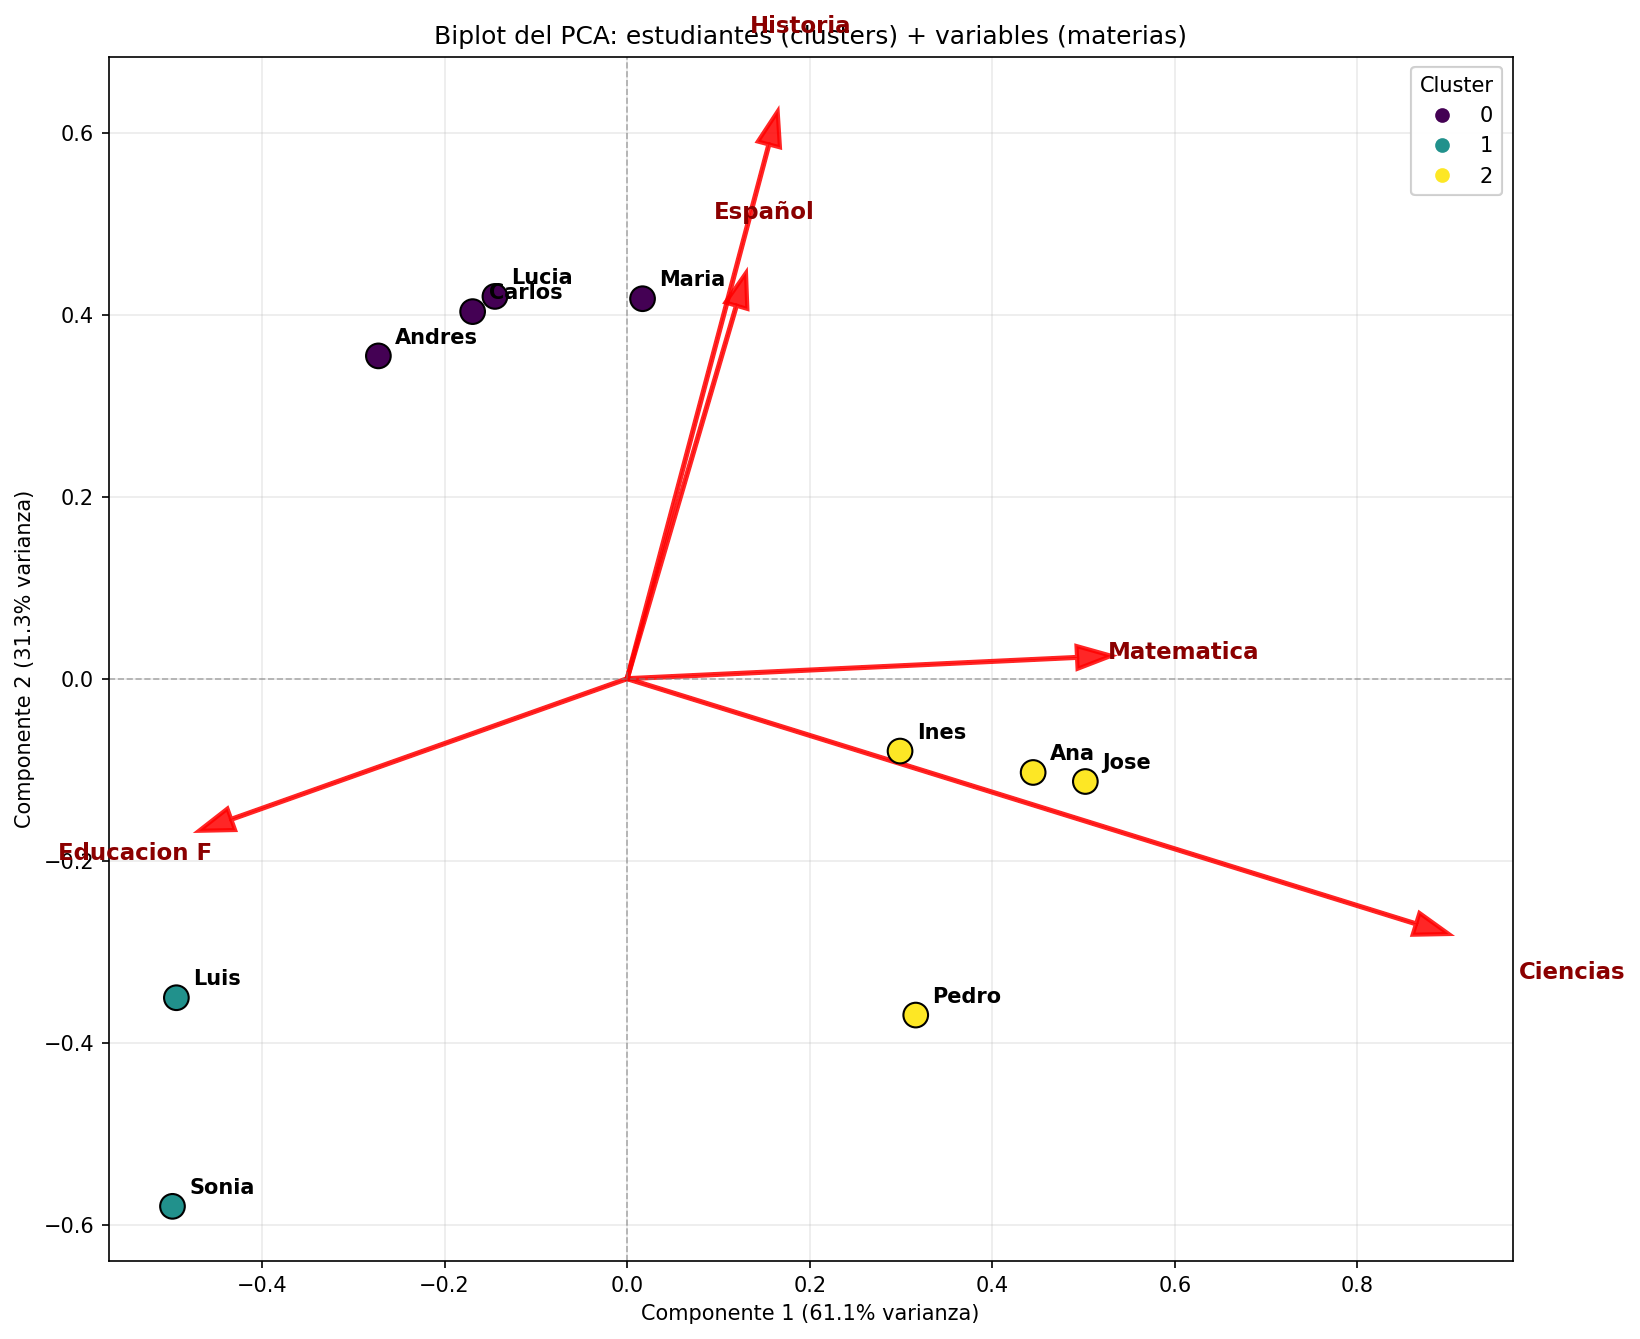

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(11, 9), dpi=150)

etiquetas = kmedias.predict(datos)

scores = componentes
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

scale_pts = 1.0 / (scores.max(axis=0) - scores.min(axis=0))
xs = scores[:, 0] * scale_pts[0]
ys = scores[:, 1] * scale_pts[1]

scatter = ax.scatter(xs, ys, c=etiquetas, cmap='viridis', s=140, edgecolor='k', zorder=3)

for i, nombre in enumerate(datos.index):
    ax.annotate(
        nombre,
        (xs[i], ys[i]),
        textcoords="offset points",
        xytext=(8, 6),
        fontsize=10,
        fontweight='bold',
        zorder=4
    )

scale_arrow = 1.0 / np.abs(loadings).max() * 0.9
for i, variable in enumerate(datos.columns):
    ax.arrow(
        0, 0,
        loadings[i, 0] * scale_arrow,
        loadings[i, 1] * scale_arrow,
        color='red',
        alpha=0.85,
        head_width=0.025,
        length_includes_head=True,
        linewidth=2,
        zorder=2
    )
    ax.text(
        loadings[i, 0] * scale_arrow * 1.15,
        loadings[i, 1] * scale_arrow * 1.15,
        variable,
        color='darkred',
        fontsize=11,
        fontweight='bold',
        ha='center',
        va='center',
        zorder=5
    )

ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)

var_exp = pca.explained_variance_ratio_ * 100
ax.set_xlabel(f'Componente 1 ({var_exp[0]:.1f}% varianza)')
ax.set_ylabel(f'Componente 2 ({var_exp[1]:.1f}% varianza)')
ax.set_title('Biplot del PCA: estudiantes (clusters) + variables (materias)')

legend1 = ax.legend(*scatter.legend_elements(), title='Cluster', loc='best')
ax.add_artist(legend1)

ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()